# Introduction to pointcloud & Deepset

Pipeline based on Sanmay Ganguly  tutorial on deep sets: https://github.com/sanmayphy/ICTS_ML_SCHOOL/tree/main

In [248]:
# importing the relevant functions
import torch#, torchvision, torchmetrics
import torch.utils.data as data
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
if(torch.backends.cuda.is_built()) : 
    device='cuda'
elif(torch.backends.mps.is_built()) : 
    device='mps'
else : 
    device='cpu'

# 1. Load data and make data loader

In [3]:
transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.,), (1.0,)) # mean 0 std 1.
        ])

dataset = datasets.MNIST('./data', train=True, download=True,transform=transform)
dataset # access dataset[image numebr] [0:image, 1:which numebr as a lable]

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.0,), std=(1.0,))
           )

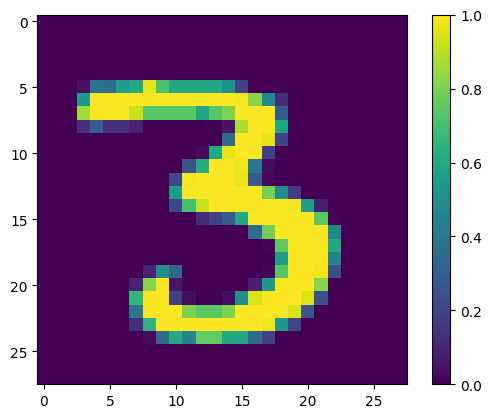

In [4]:
X,y = dataset[12]
img_array = X[0] # because X has the shape torch.Size([1, 28, 28]), we only want the [28, 28]
plt.imshow(X[0].numpy())
plt.colorbar()

In [5]:
#Our goal is to first convert the images into the set of point cloud for non-zero elements, basically as scatter plots.
# this can be acheaved by the line bellow:
coordinates_of_non_zero_example=torch.argwhere(img_array > 0.)[:,:]/img_array.shape[0] # we also devide it by 28 (size) to the coordinate be between 0-1.
coordinates_of_non_zero_example[0:5] # example of coordinates [x,y]



tensor([[0.1786, 0.1071],
        [0.1786, 0.1429],
        [0.1786, 0.1786],
        [0.1786, 0.2143],
        [0.1786, 0.2500]])

In [9]:
# def transform_2d_img_to_point_cloud(data):
    
#     img, label = data
#     img_array = img[0]
#     values = img_array[img_array > 0]
#     x_coord = torch.argwhere(img_array > 0.)[:,0]/img_array.shape[0]
#     y_coord = torch.argwhere(img_array > 0.)[:,1]/img_array.shape[0]
    
#     return torch.stack( (x_coord, y_coord, values), dim=-1), label 
#vect = transform_2d_img_to_point_cloudT(X)

In [6]:
# here we want to define a costum fuction and dataset class, the point is this gets the tensors of input dataset, and convert them to set based dataset

# this is a child class of data.Dataset. basically has some mofificatgions
class MNISTPC_Dataset(data.Dataset):

    def __init__(self, dataset_path:str, train:bool = True, download:bool =False, mean:float = 0., std:float = 1.) -> None:
        """
        Inputs:
            size - Number of data points we want to generate
            std - Standard deviation of the noise (see generate_continuous_xor function)
        """
        super().__init__()

        #__ just the normalization of data
        self.transform = transforms.Compose(
                       [
                        transforms.ToTensor(),
                        transforms.Normalize((mean,), (std,))
                       ]
                       )

        # the data set is downloaded insied the class
        self.dataset = datasets.MNIST(dataset_path, train=train, download=download,
                       transform=self.transform)
        

        # this will conver points to clpouds, will be defined later
        self.pc_dataset = [ self.transform_2d_img_to_point_cloud(self.dataset[idx]) for idx in range(len(self.dataset)) ]


    
    def transform_2d_img_to_point_cloud(self, data_i:tuple) -> dict : #data_i:tuple is  tuple because the data has also the lables. (only for labaled data.)
    
        img, label = data_i # here we unwrap the tuple
        img_array = img[0] # convertin shape from 3d to 2d.
        values = img_array[img_array > 0]
        
        x_coord = torch.argwhere(img_array > 0.)[:,0]/img_array.shape[0] # x locations
        y_coord = torch.argwhere(img_array > 0.)[:,1]/img_array.shape[0] # y locations
        
        point_vec = torch.stack( (x_coord, y_coord, values), dim=-1) # combines x y and pixel value into one tuple.
        
        return {'point' : point_vec, 'label' : label, 'seq_length' : len(point_vec)}

    
    # the Datasewt class there should always be __len__ and  __getitem__ fuctions. 
    
    def __len__(self) -> int:
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return len(self.pc_dataset)
    
    def __getitem__(self, idx:int) -> dict :
        # Return the idx-th data point of the dataset
    
        return self.pc_dataset[idx]#data_point, data_label


In [7]:
# now we can run and make a point cloud datqaset: pc_dataset
pc_dataset = MNISTPC_Dataset('./data/')

In [173]:
len(pc_dataset)

60000

In [9]:
pc_dataset[19] # {point: (x,y, value), label: , length:}

{'point': tensor([[0.2500, 0.4643, 0.0706],
         [0.2500, 0.5000, 0.4118],
         [0.2500, 0.5357, 0.8902],
         [0.2500, 0.5714, 0.9922],
         [0.2500, 0.6071, 0.9922],
         [0.2500, 0.6429, 0.4784],
         [0.2857, 0.4286, 0.2235],
         [0.2857, 0.4643, 0.7804],
         [0.2857, 0.5000, 0.9922],
         [0.2857, 0.5357, 0.9882],
         [0.2857, 0.5714, 0.9882],
         [0.2857, 0.6071, 0.9882],
         [0.2857, 0.6429, 0.9882],
         [0.2857, 0.6786, 0.6235],
         [0.3214, 0.3929, 0.0784],
         [0.3214, 0.4286, 0.8275],
         [0.3214, 0.4643, 0.9882],
         [0.3214, 0.5000, 0.9098],
         [0.3214, 0.5357, 0.5961],
         [0.3214, 0.5714, 0.2863],
         [0.3214, 0.6071, 0.6549],
         [0.3214, 0.6429, 0.9882],
         [0.3214, 0.6786, 0.8431],
         [0.3214, 0.7143, 0.0235],
         [0.3571, 0.3929, 0.7725],
         [0.3571, 0.4286, 0.9882],
         [0.3571, 0.4643, 0.7137],
         [0.3571, 0.6071, 0.1451],
         [0

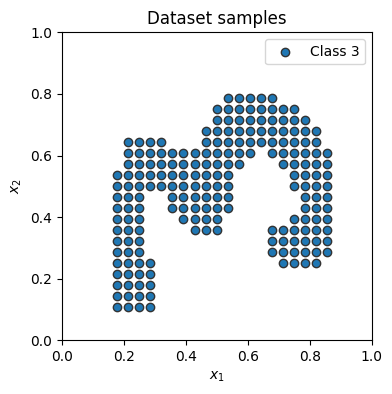

In [10]:
# converts point cloud data into a plot:
def visualize_samples(data_, label, marker='o'):
    if isinstance(data_, torch.Tensor):
        data_ = data_.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
        
    plt.figure(figsize=(4,4))
    plt.scatter(data_[:,0] , data_[:,1], edgecolor="#333", marker=marker, label="Class " + str(label))
    
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.legend()

index=12
pc, label = pc_dataset[index]['point'], pc_dataset[index]['label']
visualize_samples(pc, label)

# 2. Define the mini batches for training

In [169]:
# important: this the the numebr of scatter points that our paddig strategy will take:
#Pads if the set has fewer than K elements OR Randomly downsamples if the set has more than K elements
N_elements_in_set=128

In [142]:


def create_batch(data_list: list, K: int = N_elements_in_set) -> tuple:

    pc_list = []      # will store processed point clouds
    label_list = []   # will store labels

    for idx in range(len(data_list)):

        pc = data_list[idx]['point']     # point cloud tensor (N, C)
        label = data_list[idx]['label']  # label for this set

        N, C = pc.shape                  # N = number of points, C = feature dim

        # ---- Case 1: too many points -> random downsampling ----
        if N > K:
            # randomly choose K indices without replacement
            indices = torch.randperm(N)[:K]
            pc_fixed = pc[indices]

        # ---- Case 2: fewer points -> padding ----
        elif N < K:
            # create zero padded tensor (K, C)
            pc_fixed = torch.zeros(K, C)

            # copy the real points into the beginning
            pc_fixed[:N] = pc

        # ---- Case 3: exactly K points ----
        else:
            pc_fixed = pc

        # reshape to include batch dimension (1, K, C)
        pc_fixed = pc_fixed.unsqueeze(0)

        pc_list.append(pc_fixed)
        label_list.append(torch.tensor([label]))

    # concatenate all sets into a batch
    # final shape: (B, K, C)
    batch_pc = torch.cat(pc_list, dim=0)

    # labels shape: (B,)
    batch_labels = torch.cat(label_list, dim=0)

    return batch_pc, batch_labels

In [143]:
type(pc_dataset)

__main__.MNISTPC_Dataset

In [144]:
pc_dataloader = data.DataLoader(dataset=pc_dataset, batch_size=5, shuffle=True, collate_fn=create_batch)

pc_chunk, label_chunk = next(iter(pc_dataloader))

pc_chunk.shape, label_chunk.shape

(torch.Size([5, 128, 3]), torch.Size([5]))

# 3 making the Endcoder-z-Decoder

## 3.1 Define the basic deepset layer for encoder

A permutation equivariant layer is defined as 
$$ 
x' = \Theta. x \equiv \gamma \mathbb{I}.x + \lambda (\mathbb{I} \mathbb{I}^T) . x~~~\lambda \,, \gamma \in \mathbb{R}
$$ 

Assuming $x = (x_1, x_2, x_3)^T$, the above equation becomes : 
$$
\begin{pmatrix}
x_1' \\
x_2' \\
x_3' 
\end{pmatrix}
= \gamma 
\begin{pmatrix}
1 && 0 && 0 \\
0 && 1 && 0 \\
0 && 0 && 1
\end{pmatrix} 
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix} + 
\lambda
\begin{pmatrix}
1 && 1 && 1 \\
1 && 1 && 1 \\
1 && 1 && 1
\end{pmatrix}  
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix} \\ \\
= 
\begin{pmatrix}
(\gamma + \lambda)x_1 + \lambda(x_2 + x_3)\\
(\gamma + \lambda)x_2 + \lambda(x_1 + x_3) \\
(\gamma + \lambda)x_3 + \lambda(x_1 + x_2) 
\end{pmatrix} \\ \\
= (\gamma + \lambda)
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix}
- \lambda
\begin{pmatrix}
x_1 - \sum x_i\\
x_2 - \sum x_i\\
x_3 - \sum x_i
\end{pmatrix}
= \Gamma .x + \Lambda.\Big(x - \alpha(x) \Big)
$$


In [147]:
class DeepSet_Linear_Layer(nn.Module):
    def __init__(self, in_features:int, out_features:int,  normalization:str = '', pool:str = 'mean') -> None :
        """
        DeepSets single layer
        :param in_features: input's number of features
        :param out_features: output's number of features
        :param attention: Whether to use attention
        :param normalization: normalization method - 'fro' or 'batchnorm'
        
        """
        super(DeepSet_Linear_Layer, self).__init__()

        self.Gamma = nn.Linear(in_features, out_features) # linear is [multiplication and bias]
        self.Lambda = nn.Linear(in_features, out_features)

        self.normalization = normalization
        self.pool = pool
        
        if normalization == 'batchnorm':
            self.bn = nn.BatchNorm1d(out_features)

    def forward(self, x : torch.Tensor) -> torch.Tensor :
        # x.shape = (B, N, C),  x is a minimbatch. B: batch size, N:numebr of points in that set ,C:dimenssion of fatures

        # difference between mean and max is the choice of permiation invariant a(x)
        if(self.pool == 'mean') : 
            x = self.Gamma(x) + self.Lambda(x-x.mean(dim=1, keepdim=True)) # -- the average is over the points -- #
            
        elif(self.pool == 'max') :
            x = self.Gamma(x) + self.Lambda(x-x.max(dim=1, keepdim=True)) # -- the max is over the points -- #

        # normalization
        if self.normalization == 'batchnorm':
            x = self.bn(x)
        
        return x

In [145]:
pc_chunk.shape

torch.Size([5, 128, 3])

In [146]:
ds_layer = DeepSet_Linear_Layer(in_features = 3, out_features = 4)
y = ds_layer(pc_chunk)
pc_chunk.shape, y.shape

(torch.Size([5, 128, 3]), torch.Size([5, 128, 4]))

## 4 Make the full auto encoder

In [148]:
class DeepSet_Auto_encoder_v1(nn.Module):
    def __init__(self, 
                 in_features:int, 
                 feats_encoder:list, 
                 feats_latent:int,
                 feats_decoder:list,
                 N_elements_in_set: int,
                 normalization:str = '', 
                 pool:str = 'mean') ->None:
        
        """
        DeepSets architecture for set classification.

        Input:
            x ∈ R^{B × N × C}
                B : batch size
                N : number of elements in the set
                C : feature dimension per element

        A-The Endcoder follows the DeepSets structure: (where g(X) is implemented by stacking equivariant layers.)

            X → g(X) (permutation equivariant network)
              → pooling (permutation invariant)
              → Latent_Z
        
        B-The decoder is just an MLP:
            Latent_Z → h(Z) = predicted X
            
        
        
        Parameters
        ----------
        in_features : int
            Dimensionality of each element in the input set.

        feats_encoder : list[int]
            Hidden feature sizes for the stacked equivariant layers.
            Example: [64,128,256]

        feats_latent : int
            The size of the latent space (let's say 16)

        feats_decoder : list[int]
            Hidden feature sizes for the stacked MLP of the decoder.

        N_elements_in_set: int
        numebr of elements in each set. Note that the last layer of MLP should have (in_features*K_elements_in_set) neurons


        normalization : str
            Optional normalization method ('batchnorm' or '').

        pool : str
            Permutation-invariant aggregation used inside the equivariant layer
            (e.g. 'mean' or 'max').
        """
        
        super(DeepSet_Auto_encoder_v1, self).__init__()

        
        self.in_features = in_features
        self.feats_encoder=feats_encoder
        self.feats_latent=feats_latent
        self.feats_decoder=feats_decoder
        self.N_elements_in_set = N_elements_in_set


        
        # ------------------------------ encoder: (B,N,C)→(B,N,H) ------------------------------------
        layers = []
        # Stack multiple equivariant non-linear blocks:
        # equivariant linear layer mplements the transformation y_i = Γ x_i + Λ a(X) where a(X) is a permutation-invariant summary of the set (e.g. mean or max across elements).
        #nonlinearities (ReLU here) are applied element-wise, so permutation equivariance is preserved.

        # first layer
        layers.append(DeepSet_Linear_Layer(in_features, feats_encoder[0], normalization, pool))
        layers.append(nn.ReLU())
        
        # remaining layers
        for i in range(1, len(feats_encoder)):
            layers.append(DeepSet_Linear_Layer(feats_encoder[i-1], feats_encoder[i], normalization, pool))
            layers.append(nn.ReLU())
        
        # store encoder layers
        self.encoder = nn.ModuleList(layers) # note that encoder dimenssion (B,N,C)→(B,N,feats_endcoder[-1])

        
        # ------------------------------ Pooling: (B,N,feats_endcoder[-1])→(B,feats_endcoder[-1]) ------------------------------------
        #Will do the pooling in the forward path, because is a fuctnion: via   "x = x.mean(dim=1)" or sum

        
        # ------------------------------ Latent layer Z: (B,feats_endcoder[-1])→(B,d_z) ------------------------------------
        #note that this is NOT permutation equivariant anymore, but because of poolig, will be invariant
        self.latent_layer = nn.Linear(feats_encoder[-1], feats_latent)



        # ------------------------------ Decoder: (B,d_z)→(B, N*C)→[re-organize]→(B, N,C) ------------------------------------
        # this will decode the latent space stepwise evnetually into N*C neurons. then reorganize it into output shaped (B, N,C) 
        layers = []

        # first decoder layer: latent -> first hidden decoder size
        layers.append(nn.Linear(feats_latent, feats_decoder[0]))
        layers.append(nn.ReLU())
        
        # intermediate decoder layers
        for i in range(1, len(feats_decoder)):
            layers.append(nn.Linear(feats_decoder[i-1], feats_decoder[i]))
            layers.append(nn.ReLU())


        # last layer, note that C:in_features and N:N_elements_in_set. Also last hidden -> flattened set
        # note there is no Relu after, to make sure output is not constrained to positive values.
        layers.append(nn.Linear(feats_decoder[-1], in_features * N_elements_in_set))

        #now reshaping to match exactly the shape of input
        # will be done in the forward part as: x = x.view(B, N_elements_in_set, in_features)

        self.decoder = nn.ModuleList(layers)



    def forward(self, x):
        #-------encoders-------
        for layer in self.encoder:
            x = layer(x)   # (B,N,H)
        # pooling
        x = x.mean(dim=1)  # (B,H)

        #-------latent-------
        z = self.latent_layer(x)  # (B,d_z)

        #-------decoder-------
        x_hat = z
        for layer in self.decoder:
            x_hat = layer(x_hat)  # (B, N*C)
    
        B = x_hat.shape[0] #this is the batch size
        x_hat = x_hat.reshape(B, self.N_elements_in_set, self.in_features)
    
        return x_hat, z


In [219]:
# define and load the model
in_features_=3
feats_encoder_=[5, 9, 12, 16, 13] 
feats_latent_=4
feats_decoder_=[32,64,128]
model = DeepSet_Auto_encoder_v1(in_features=in_features_,
                                feats_encoder=feats_encoder_, 
                                feats_latent=feats_latent_, 
                                feats_decoder=feats_decoder_,
                                N_elements_in_set=N_elements_in_set)

model = model.to(device)
y, z = model(pc_chunk.to(device))

In [220]:
y.shape, label_chunk.shape, z.shape

(torch.Size([5, 128, 3]), torch.Size([5]), torch.Size([5, 4]))

In [221]:
pc_chunk.shape

torch.Size([5, 128, 3])

In [222]:
# simple example loss, note it is wrong because it is not permuation invariant
F.mse_loss(y, pc_chunk.to(device))

tensor(0.4025, device='cuda:0', grad_fn=<MseLossBackward0>)

In [223]:
torch.backends.mps.is_built() # for apple M4

False

### 5 define a proper loss function
$$d_{\text{Chamfer}}(\hat X, X)
=
\sum_{\hat x \in \hat X}\min_{x \in X}\|\hat x-x\|^2
+
\sum_{x \in X}\min_{\hat x \in \hat X}\|x-\hat x\|^2$$

Note that we use L2^2 version bellow, for stability

In [224]:
def chamfer_loss(x_hat, x):
    """
    x_hat : (B, N_pred, C)
    x     : (B, N_true, C)
    """
    # pairwise squared distances
    dist_sq = torch.cdist(x_hat, x) ** 2

    # closest predicted -> true
    min_dist_pred = dist_sq.min(dim=2).values

    # closest true -> predicted
    min_dist_true = dist_sq.min(dim=1).values

    # symmetric Chamfer loss
    loss = min_dist_pred.mean() + min_dist_true.mean()

    return loss

In [225]:
# check if the chamfer_loss works?
chamfer_loss(y, pc_chunk.to(device))

tensor(1.1004, device='cuda:0', grad_fn=<AddBackward0>)

## 6 creating the training anf the testing block

In [226]:
def train(model, device, train_loader, optimizer):
    
    train_loss_ep = 0.
    
    model.train()
    
    for batch_idx, (data, target) in enumerate(train_loader):
        
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        x_hat, z = model(data)
        
        # note that here we will not really need the "target" for Autoencoders, since it is the lables
        loss=chamfer_loss(x_hat,data) # the data is the target, since it is an Autoencoders
        
        loss.backward()
        
        optimizer.step()
        
        train_loss_ep += loss.item() * data.size(0)
        
    return train_loss_ep




def test(model, device, test_loader):
    
    test_loss_ep = 0.0
    model.eval()
    
    with torch.no_grad():  # disable gradient tracking
        
        for batch_idx, (data, target) in enumerate(test_loader):
            
            data = data.to(device)
            
            x_hat, z = model(data)
            
            # reconstruction loss
            loss = chamfer_loss(x_hat, data)
            
            test_loss_ep += loss.item() * data.size(0)
        
    return test_loss_ep

## 7 Let's prepare the full dataset and dataloaders

In [227]:
import torch.utils.data as data

# number of subprocesses to use for data loading
num_workers = 5

# how many samples per batch to load
batch_size = 5

# percentage of training set to use as validation
valid_size = 0.2

# # convert data to torch.FloatTensor
# transform = transforms.ToTensor()
# choose the training and testing datasets
train_data =  MNISTPC_Dataset('./data/', train = True, download = True)
test_data = MNISTPC_Dataset('./data/', train = False, download = True)
# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_index, valid_index = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_index)
valid_sampler = SubsetRandomSampler(valid_index)
# prepare data loaders

train_loader = data.DataLoader(dataset=train_data, batch_size = batch_size, 
                                           num_workers = num_workers, sampler = train_sampler, collate_fn=create_batch)
valid_loader = data.DataLoader(train_data, batch_size = batch_size,
                                          num_workers = num_workers,  sampler = valid_sampler, collate_fn=create_batch)
test_loader = data.DataLoader(test_data, batch_size = batch_size,
                                                     num_workers = num_workers, shuffle=False, collate_fn=create_batch)


In [228]:
model = model.to(device=device)

In [229]:
#optimizer = torch.optim.SGD(model.parameters(),lr = 0.01)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    #weight_decay=1e-4
    )

## 8 Run the training loop 

In [230]:
# number of epochs to train the model
n_epochs = 10
# initialize tracker for minimum validation loss
valid_loss_min = np.Inf  # set initial "min" to infinity
for epoch in range(n_epochs):
    # monitor losses
    
    train_loss = train(model, device, train_loader, optimizer)
    
    valid_loss = test(model, device, valid_loader)
    
    # print training/validation statistics 
    # calculate average loss over an epoch
    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)
    
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch+1, 
        train_loss,
        valid_loss
        ))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 0.015017 	Validation Loss: 0.011882
Validation loss decreased (inf --> 0.011882).  Saving model ...
Epoch: 2 	Training Loss: 0.011150 	Validation Loss: 0.010627
Validation loss decreased (0.011882 --> 0.010627).  Saving model ...
Epoch: 3 	Training Loss: 0.010109 	Validation Loss: 0.009810
Validation loss decreased (0.010627 --> 0.009810).  Saving model ...
Epoch: 4 	Training Loss: 0.009717 	Validation Loss: 0.009543
Validation loss decreased (0.009810 --> 0.009543).  Saving model ...
Epoch: 5 	Training Loss: 0.009560 	Validation Loss: 0.009617
Epoch: 6 	Training Loss: 0.009468 	Validation Loss: 0.009461
Validation loss decreased (0.009543 --> 0.009461).  Saving model ...
Epoch: 7 	Training Loss: 0.009399 	Validation Loss: 0.009368
Validation loss decreased (0.009461 --> 0.009368).  Saving model ...
Epoch: 8 	Training Loss: 0.009342 	Validation Loss: 0.009332
Validation loss decreased (0.009368 --> 0.009332).  Saving model ...
Epoch: 9 	Training Loss: 0.009301 

## Load the best saved model and use it for test performance

In [231]:
model_test = DeepSet_Auto_encoder_v1(in_features=in_features_,
                                     feats_encoder=feats_encoder_, 
                                    feats_latent=feats_latent_, 
                                    feats_decoder=feats_decoder_,
                                    N_elements_in_set=N_elements_in_set)

model_test.load_state_dict(torch.load('model.pt'))
model_test.to(device)



DeepSet_Auto_encoder_v1(
  (encoder): ModuleList(
    (0): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=3, out_features=5, bias=True)
      (Lambda): Linear(in_features=3, out_features=5, bias=True)
    )
    (1): ReLU()
    (2): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=5, out_features=9, bias=True)
      (Lambda): Linear(in_features=5, out_features=9, bias=True)
    )
    (3): ReLU()
    (4): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=9, out_features=12, bias=True)
      (Lambda): Linear(in_features=9, out_features=12, bias=True)
    )
    (5): ReLU()
    (6): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=12, out_features=16, bias=True)
      (Lambda): Linear(in_features=12, out_features=16, bias=True)
    )
    (7): ReLU()
    (8): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=16, out_features=13, bias=True)
      (Lambda): Linear(in_features=16, out_features=13, bias=True)
    )
    (9): ReLU()
  )
  (latent_layer): Linear(i

In [232]:
def eval_model(model, data_loader, device):
    model.eval()  # evaluation mode
    total_loss = 0.0
    num_samples = 0

    with torch.no_grad():  # no gradients during evaluation
        for data_inputs, _ in data_loader:
            
            data_inputs = data_inputs.to(device)

            # forward pass
            x_hat, z = model(data_inputs)

            # reconstruction loss
            loss = chamfer_loss(x_hat, data_inputs)

            # accumulate weighted by batch size
            batch_size = data_inputs.shape[0]
            total_loss += loss.item() * batch_size
            num_samples += batch_size

    avg_loss = total_loss / num_samples
    print(f"Average reconstruction Chamfer loss: {avg_loss:.6f}")

In [233]:
eval_model(model_test, test_loader,device=device)

Average reconstruction Chamfer loss: 0.009128


## lookinf at recostructions of Autoencoder

In [245]:
import torch
import matplotlib.pyplot as plt
import numpy as np


@torch.no_grad()
def show_reconstruction_examples(model, loader, device, n_show_examples=20, n_per_row=5):

    model.eval()

    x_list = []
    xhat_list = []

    # collect examples across batches
    for x, _ in loader:
        x = x.to(device)
        x_hat, z = model(x)

        x_list.append(x.cpu())
        xhat_list.append(x_hat.cpu())

        n_collected = sum(chunk.shape[0] for chunk in x_list)

        if n_collected >= n_show_examples:
            break

    # concatenate
    x_all = torch.cat(x_list, dim=0).numpy()
    xhat_all = torch.cat(xhat_list, dim=0).numpy()

    x_all = x_all[:n_show_examples]
    xhat_all = xhat_all[:n_show_examples]

    # compute grid shape
    n_cols = n_per_row
    n_rows = int(np.ceil(n_show_examples / n_cols))

    fig = plt.figure(figsize=(4 * n_cols, 4 * n_rows))

    for i in range(n_show_examples):

        ax = fig.add_subplot(n_rows, n_cols, i + 1)

        # original set
        ax.scatter(
            x_all[i, :, 0],
            x_all[i, :, 1],
            s=45,
            c='grey',
            alpha=0.6,
            label="x"
        )

        # reconstruction
        ax.scatter(
            xhat_all[i, :, 0],
            xhat_all[i, :, 1],
            s=25,
            c='blue',
            alpha=0.9,
            label="x_hat"
        )

        ax.set_title(f"Example {i}")
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")

    # show legend once
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()

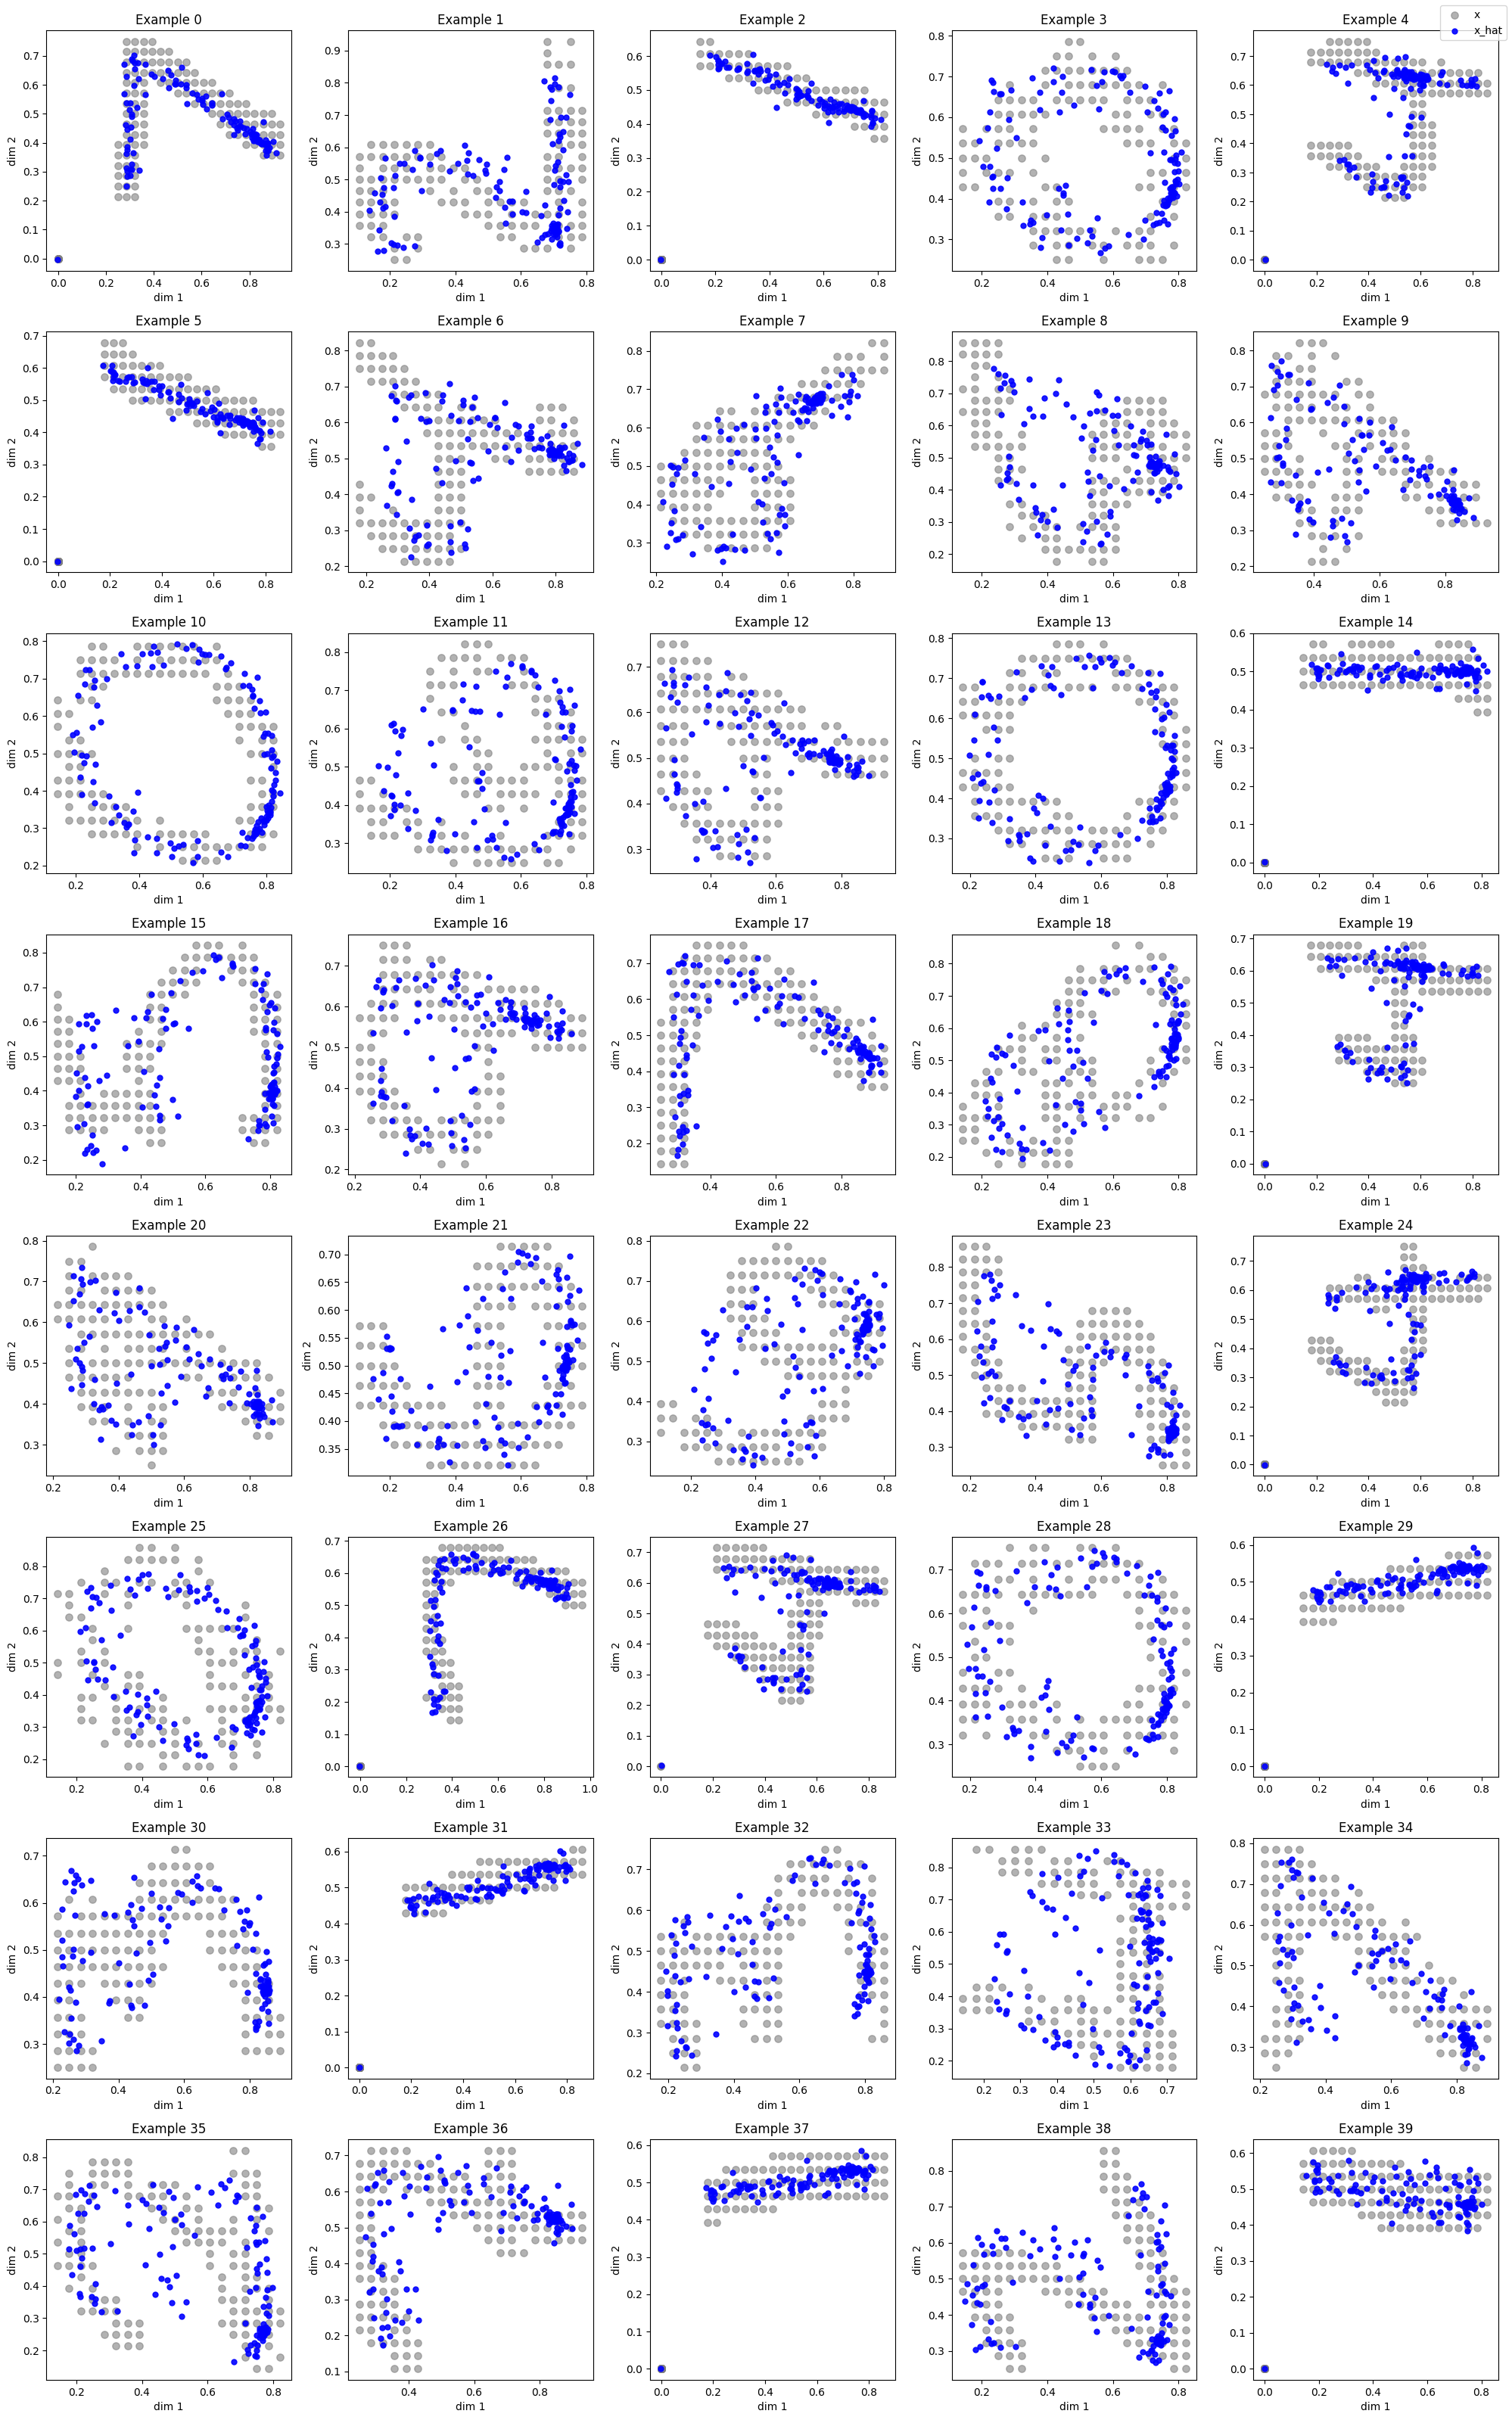

In [246]:
show_reconstruction_examples(model, test_loader, device, n_show_examples=40)

## 7 now looking at the latent represetation of numbers?

In [236]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


@torch.no_grad()
def collect_all_sets_z(model, loader, device):
    """
    Run a full forward pass through the autoencoder and collect
    the latent vector z for every set.

    Autoencoder forward:
        x_hat, z = model(x)

    Shapes:
        x     : (B, N, C)
        z     : (B, latent_dim)

    Returns
    -------
    Z : np.ndarray
        Latent matrix of shape (num_sets, latent_dim)

    y : np.ndarray
        Labels of shape (num_sets,)
        Note: labels are not used for training the autoencoder,
        but we keep them here only for visualization.
    """
    model.eval()

    Z_chunks = []
    y_chunks = []

    for x, y in loader:
        x = x.to(device)

        # forward pass through the autoencoder
        x_hat, z = model(x)

        # store latent vectors and labels
        Z_chunks.append(z.cpu())
        y_chunks.append(y.cpu())

    Z = torch.cat(Z_chunks, dim=0).numpy()
    y = torch.cat(y_chunks, dim=0).numpy()

    return Z, y


def pca_and_highlight_digits(Z, y):
    """
    Fit PCA globally on all latent vectors Z and plot the 2D projection.
    All points are shown faintly in the background, then each digit is highlighted.
    """
    pca = PCA(n_components=2)
    Z2 = pca.fit_transform(Z)

    plt.figure()

    # background: all points
    plt.scatter(Z2[:, 0], Z2[:, 1], s=8, alpha=0.15)

    # overlay each digit
    for digit in range(10):
        idx = (y == digit)
        if np.any(idx):
            plt.scatter(
                Z2[idx, 0],
                Z2[idx, 1],
                s=15,
                alpha=0.9,
                label=str(digit)
            )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA of autoencoder latent space (z)")
    plt.legend(title="digit")
    plt.tight_layout()
    plt.show()

    print("Latent dimension (z):", Z.shape[1])
    print("PCA explained variance ratio:", pca.explained_variance_ratio_)


def umap_and_highlight_digits(Z, y, n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42):
    """
    Fit UMAP globally on all latent vectors Z and plot the 2D embedding.
    All points are shown faintly in the background, then each digit is highlighted.

    Parameters
    ----------
    Z : np.ndarray
        Latent vectors of shape (num_sets, latent_dim)

    y : np.ndarray
        Labels of shape (num_sets,)

    n_neighbors : int
        Controls locality vs global structure.

    min_dist : float
        Controls cluster compactness.

    metric : str
        Distance metric used by UMAP.

    random_state : int
        Random seed for reproducibility.
    """
    try:
        import umap.umap_ as umap
    except ImportError:
        raise ImportError(
            "UMAP is not installed. Install it with:\n"
            "pip install umap-learn"
        )

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state
    )

    Z2 = reducer.fit_transform(Z)

    plt.figure()

    # background: all points
    plt.scatter(Z2[:, 0], Z2[:, 1], s=8, alpha=0.12)

    # overlay each digit
    for digit in range(10):
        idx = (y == digit)
        if np.any(idx):
            plt.scatter(
                Z2[idx, 0],
                Z2[idx, 1],
                s=15,
                alpha=0.9,
                label=str(digit)
            )

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("UMAP of autoencoder latent space (z)")
    plt.legend(title="digit")
    plt.tight_layout()
    plt.show()




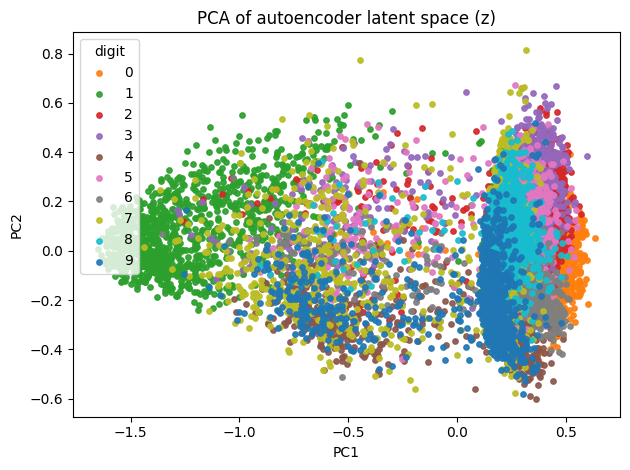

Latent dimension (z): 4
PCA explained variance ratio: [0.7700078  0.11420393]


/home/tiamheydari/anaconda3/envs/nn/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tiamheydari/anaconda3/envs/nn/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


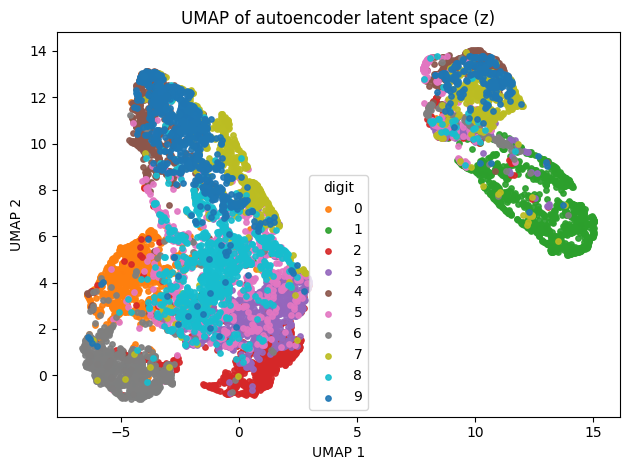

In [237]:
# ----------------------------
# Example usage
# ----------------------------
Z, y = collect_all_sets_z(model, test_loader, device)
pca_and_highlight_digits(Z, y)
umap_and_highlight_digits(Z, y)